<a href="https://colab.research.google.com/github/rileymo97/DevOpsProject/blob/main/Notebook2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data and the State (DATA 20195/30195)
# Lab 2: The Decennial Census (blocks) and the ACS

In Lab 1, we focused on county-level data in Illinois. In this lab we go deeper in two directions:

1. **Finer geography:** from counties down to individual census **blocks**, the smallest unit in the Census hierarchy.
2. **Richer data:** from the decennial Census to the **American Community Survey (ACS)**, which covers income, housing, commuting, education, and much more.



In [1]:
!pip install -q census us

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 7.8 MB/s eta 0:00:00


In [2]:
%config InlineBackend.figure_formats = ["svg"]

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from census import Census
from us import states

state_fips  = "17"    # Illinois
county_fips = "031"   # Cook County
state_name  = "Illinois"
county_name = "Cook County"

census = Census("", year=2020)

In [3]:
# @title Check the census API is working
try:
    county_populations = census.pl.get(
        ("NAME"),
        geo={"for": "state:17"}
    )
    print("The Census API appears to be working!")
except Exception:
    raise RuntimeError(
        "Error fetching data from the Census API. "
        "Please try disconnecting and reconnecting the runtime. "
        "If the problem persists after 2 resets, you will need to use our backup data cells to "
        "complete the lab"
    )

The Census API appears to be working!


## Section 1 – The Census geographical hierarchy

The core Census geographic units are organized into hierarchy (sometimes referred to as _the central spine_): states contain counties, which contain _tracts_, which contain _block groups_, which contain _blocks_. States and counties are (mostly) static political units with boundaries generally not determined by the Census; tracts, block groups, and blocks are statistical units defined by the Census. These statistical units are subject to change for each decennial Census. Blocks are the most granular unit in this hierarchy, and [many Census blocks are unpopulated](https://mapsbynik.com/maps/census0pop/).

![U.S. Census central spine (source: University of Missouri)](https://mcdc.missouri.edu/geography/sumlevs/censusgeochart.png)

_(image credit: University of Missouri)_

The Census also publishes data for political and statistical areas that do not fall neatly along this spine. For instance, school districts nest in states, but they do not necessarily nest in counties; voting districts nest in counties, but not necessarily in tracts. But blocks are the "pixels" that everything is built from.


## Section 2 — GEOIDs and Block Level Data

Census **blocks** are the smallest unit in the hierarchy. While counties vary widely in population and tracts are designed for comparability, blocks follow physical features — streets, waterways, property lines. Some blocks have hundreds of people; many have zero.

Here we'll fetch the same P1 race table from Lab 1, but at block resolution for Cook County. The API call structure is identical; we just change `"for": "county:*"` to `"for": "block:*"` and specify the county. **Cook County has roughly 43,000 blocks**, so this could take up to a minute.

In [4]:
# @title This cell fetches block-level population data for the specified state/county exactly as we did in the last lab, stored in `block_race_df`
p1_population_columns = {
    "P1_003N": "White",     # White alone
    "P1_004N": "Black",     # Black or African American alone
    "P1_005N": "AMIN",      # American Indian and Alaska Native alone
    "P1_006N": "Asian",     # Asian alone
    "P1_007N": "NHPI",      # Native Hawaiian and Other Pacific Islander alone
    "P1_008N": "SomeOther", # Some Other Race alone
    "P1_009N": "Multi",     # Population of two or more races
}
pl_race_categories = list(p1_population_columns.values())

block_populations = census.pl.get(
    ("NAME", *p1_population_columns),
    geo={
        "for": "block:*",   # Note: we changed the "for" statement to include blocks
        "in": f"county:{county_fips} state:{state_fips}", # We now modify the "in" statment to include
                                                          # both the county and state FIPS codes
    },
)

print(f"Fetched data for {len(block_populations):,} blocks.")

# now let's make sure we're using human-readable columns, as chosen above
block_race_df = pd.DataFrame(block_populations).rename(
    columns={"NAME": "name", **p1_population_columns}
)

# The following line is just a precaution to make sure the block identifiers are strings, which might matter later on
block_race_df[["state", "county", "tract", "block"]] = block_race_df[["state", "county", "tract", "block"]].astype(str)

Fetched data for 83,018 blocks.


In [ ]:
# # This is a backup cell to load the block-level population data.

# url = "https://raw.githubusercontent.com/ds-20195/notebooks/refs/heads/main/backup_data/Notebook2_IL_pl_Cook_county_block_data.json"
# block_race_df = pd.read_json(url, dtype={"state": str, "county": str, "tract": str, "block": str})

To work with block data, it's handy to have the [GEOID](https://www.census.gov/programs-surveys/geography/guidance/geo-identifiers.html):  a numeric code the US Census Bureau uses to name their geographies.  It starts with 2 digits for the state, which is the FIPS code we already saw last time.  Then 3 digits for the county, 6 for the tract, 1 for the block group, and 3 more for the block.  (You can think of that together as four for the block.)

So for instance 482012231001050 is a block in Texas (state 48), particularly Harris County (201), tract 2231 (223100), block group 1, which is incorporated into the block code 1050.  The nice thing about this naming scheme is that you can truncate a block code to get the codes for the higher-level geounits along the spine.

GEOID20 just means the GEOID from the 2020 Census.

In [5]:
# this constructs the 15-digit complete GEOID by concatenating the pieces
# describing different hierarchical levels: state(2) + county(3) + tract(6) + block(4)
block_race_df["GEOID20"] = (
    block_race_df["state"]
    + block_race_df["county"]
    + block_race_df["tract"]
    + block_race_df["block"]
)

block_race_df

,name,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,state,county,tract,block,GEOID20
0,"Block 2000, Block Group 2, Census Tract 101, C...",40.0,138.0,3.0,0.0,0.0,18.0,14.0,17,031,010100,2000,170310101002000
1,"Block 2003, Block Group 2, Census Tract 101, C...",99.0,86.0,0.0,6.0,0.0,6.0,12.0,17,031,010100,2003,170310101002003
2,"Block 2007, Block Group 2, Census Tract 101, C...",66.0,152.0,1.0,15.0,0.0,17.0,29.0,17,031,010100,2007,170310101002007
3,"Block 2010, Block Group 2, Census Tract 101, C...",10.0,108.0,1.0,0.0,0.0,8.0,9.0,17,031,010100,2010,170310101002010
4,"Block 3001, Block Group 3, Census Tract 101, C...",102.0,21.0,0.0,7.0,0.0,1.0,5.0,17,031,010100,3001,170310101003001
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83013,"Block 0005, Block Group 0, Census Tract 9900, ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,17,031,990000,0005,170319900000005
83014,"Block 0001, Block Group 0, Census Tract 9900, ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,17,031,990000,0001,170319900000001
83015,"Block 0003, Block Group 0, Census Tract 9900, ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,17,031,990000,0003,170319900000003
83016,"Block 0004, Block Group 0, Census Tract 9900, ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,17,031,990000,0004,170319900000004


In [6]:
# Since GEOID is a unique identifier for each block, it is a good choice as an index for our dataframe.
block_race_df = block_race_df.set_index("GEOID20")

# ⚠️ NEW SYNTAX: We have encoded all of the information that is present in the columns
# "name", "state", "county", "tract", and "block" into the GEOID20 column, so we can drop
# those extra columns.
block_race_df = block_race_df.drop(
    columns=["name", "state", "county", "tract", "block"]
)

# Now we convert the population columns to integers rather than strings, which is good data practice
# so we can do integer operations on them, like summing.
block_race_df[pl_race_categories] = block_race_df[pl_race_categories].astype(int)

block_race_df["total"] = block_race_df[pl_race_categories].sum(axis=1)
block_race_df

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total
GEOID20,,,,,,,,
170310101002000,40,138,3,0,0,18,14,213
170310101002003,99,86,0,6,0,6,12,209
170310101002007,66,152,1,15,0,17,29,280
170310101002010,10,108,1,0,0,8,9,136
170310101003001,102,21,0,7,0,1,5,136
...,...,...,...,...,...,...,...,...
170319900000005,0,0,0,0,0,0,0,0
170319900000001,0,0,0,0,0,0,0,0
170319900000003,0,0,0,0,0,0,0,0


In [ ]:
# Now we can compute the percentage of each racial category for each block, being careful to
# handle zero division errors by filling NaN values with 0.
for col in pl_race_categories:
    block_race_df[f"{col}_pct"] = (
        100 * block_race_df[col] / block_race_df["total"]
    ).fillna(0) # <- this fills any NaN values with 0, which can happen when the total population is 0

block_race_df

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct
GEOID20,,,,,,,,,,,,,,,
170310101002000,40,138,3,0,0,18,14,213,18.779343,64.788732,1.408451,0.000000,0.0,8.450704,6.572770
170310101002003,99,86,0,6,0,6,12,209,47.368421,41.148325,0.000000,2.870813,0.0,2.870813,5.741627
170310101002007,66,152,1,15,0,17,29,280,23.571429,54.285714,0.357143,5.357143,0.0,6.071429,10.357143
170310101002010,10,108,1,0,0,8,9,136,7.352941,79.411765,0.735294,0.000000,0.0,5.882353,6.617647
170310101003001,102,21,0,7,0,1,5,136,75.000000,15.441176,0.000000,5.147059,0.0,0.735294,3.676471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170319900000005,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
170319900000001,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
170319900000003,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000


That dataframe view shows that some blocks have zero people, while others have hundreds. Let's get a sense of the largest and smallest.

In [ ]:
# sorts by total population, largest to smallest
block_race_df.sort_values("total", ascending=False)

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct
GEOID20,,,,,,,,,,,,,,,
170318435001012,430,3482,8,32,0,325,412,4689,9.170399,74.258904,0.170612,0.682448,0.000000,6.931115,8.786522
170313201011003,2099,124,3,737,0,64,256,3283,63.935425,3.777033,0.091380,22.448980,0.000000,1.949436,7.797746
170313201013003,1719,125,13,687,0,52,246,2842,60.485574,4.398311,0.457424,24.173118,0.000000,1.829697,8.655876
170313907003004,420,1080,1,706,0,50,116,2373,17.699115,45.512010,0.042141,29.751370,0.000000,2.107038,4.888327
170317608011013,852,129,1,1075,2,102,103,2264,37.632509,5.697880,0.044170,47.482332,0.088339,4.505300,4.549470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170318290001012,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
170318290001014,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
170318016031000,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


#### TASK 1

By inspecting the above view, you can find the GEOID of the most populous block in Cook County and figure out its population.

Using boolean filtering, find all blocks in Cook County that are at least 50% Asian. (Think about whether it makes sense to include zero-pop blocks.)

In [ ]:
# YOUR CODE HERE

# raise your hand and ask for help if you get stuck!

#### TASK 2

How many census blocks in Cook County have more than 75% of their population made up of a single Census race?

In [ ]:
# YOUR CODE HERE

# raise your hand and ask for help if you get stuck!

### Population Distribution and Power Laws



Let's check out the distribution of TOTPOP across census blocks in Cook County.

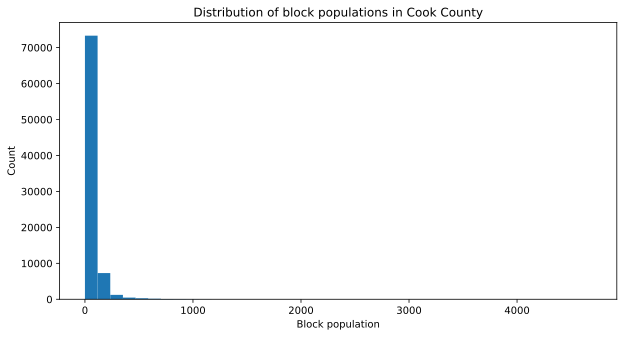

In [ ]:
# histogram of block *populations* — how many people live in each block?
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(block_race_df["total"], bins=40)
ax.set_xlabel("Block population")
ax.set_ylabel("Count")
ax.set_title(f"Distribution of block populations in {county_name}")
plt.show()

### DISCUSSION: Awkward Histogram

That viz is pretty lousy, for a few reasons.  Discuss!

We'll walk through a few alternatives just to give you ideas.  A core skill you are trying to build is making good viz, and there's a lot of data-common-sense that goes into that.

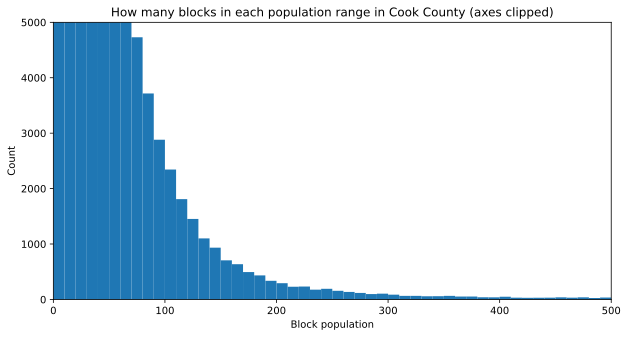

In [ ]:
# a version that clips both axes
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(block_race_df["total"], bins=range(0, 510, 10))
ax.set_xlim(0, 500)
ax.set_ylim(0, 5000)
ax.set_xlabel("Block population")
ax.set_ylabel("Count")
ax.set_title(f"How many blocks in each population range in {county_name} (axes clipped)")
plt.show()

Most blocks have very small populations — many are zero. A few are very large. This kind of highly right-skewed distribution is typical of lots of statistics -- not just population of Census blocks.  This kind of shape is called a [power law](https://en.wikipedia.org/wiki/Power_law).

In [ ]:
# find the max so we can take that into account when plotting
block_race_df["total"].max()

4689

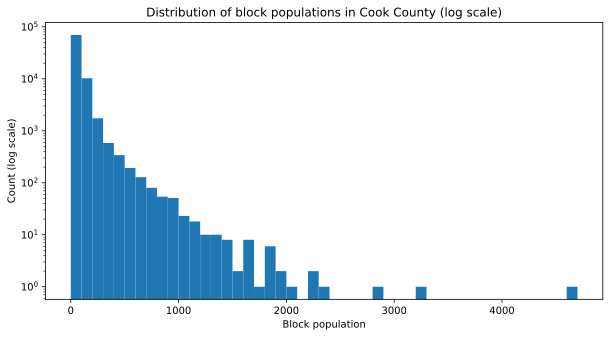

In [ ]:
# let's switch to a log scale instead
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(block_race_df["total"], bins=range(0, 4800, 100)) # play around with bin size!!
ax.set_yscale("log")
ax.set_xlabel("Block population")
ax.set_ylabel("Count (log scale)")
ax.set_title(f"Distribution of block populations in {county_name} (log scale)")
plt.show()

We'll start to see some different characteristic patterns when we fold in race.

In [ ]:
# @title This cell gets county-level population data for IL and saves to `county_race_df`

county_populations = census.pl.get(
    ("NAME", *p1_population_columns),
    geo={"for": "county:*", "in": f"state:{state_fips}"},
)
county_race_df = (
    pd.DataFrame(county_populations)
    .rename(columns={"NAME": "name", **p1_population_columns})
    .set_index("name")
    .drop(columns=["state", "county"])
)
county_race_df[pl_race_categories] = county_race_df[pl_race_categories].astype(int)
county_race_df["total"] = county_race_df[pl_race_categories].sum(axis=1)
for col in pl_race_categories:
    county_race_df[f"{col}_pct"] = (100 * county_race_df[col] / county_race_df["total"]).fillna(0)

print("First 5 rows of 'county_race_df':")
county_race_df.head()

First 5 rows of 'county_race_df':


,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct
name,,,,,,,,,,,,,,,
"Adams County, Illinois",58837,2501,104,513,39,526,3217,65737,89.503628,3.804555,0.158206,0.780382,0.059327,0.800158,4.893743
"Alexander County, Illinois",3311,1617,24,6,0,20,262,5240,63.187023,30.858779,0.458015,0.114504,0.000000,0.381679,5.000000
"Bond County, Illinois",14446,1077,52,105,11,360,674,16725,86.373692,6.439462,0.310912,0.627803,0.065770,2.152466,4.029895
"Boone County, Illinois",38766,1245,498,659,24,6176,6080,53448,72.530310,2.329367,0.931747,1.232974,0.044903,11.555156,11.375543
"Brown County, Illinois",4779,1054,11,12,0,210,178,6244,76.537476,16.880205,0.176169,0.192184,0.000000,3.363229,2.850737


In [ ]:
# # This is a backup cell to load the county-level population data.

# url = "https://raw.githubusercontent.com/ds-20195/notebooks/refs/heads/main/backup_data/Notebook2_IL_pl_county_data.json"
# county_race_df = pd.read_json(url)
# county_race_df.index.name = "name"

We've studied TOTPOP; now let's look at BPOP (Black population). We'll begin at the county level.

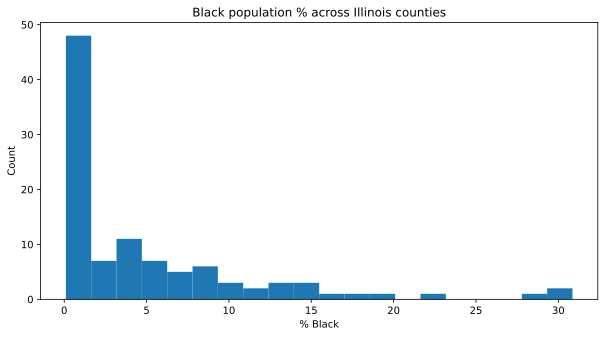

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(county_race_df["Black_pct"], bins=20)
ax.set_xlabel("% Black")
ax.set_ylabel("Count")
ax.set_title(f"Black population % across {state_name} counties")
plt.show()

The shape we see here will be much more pronounced when we pass to the block level.

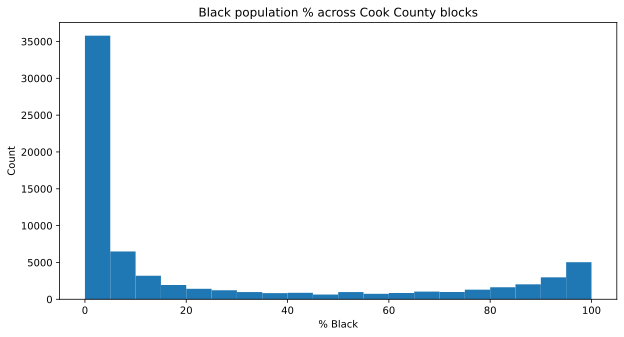

In [ ]:
# ⚠️ NEW SYNTAX: When filtering, you can use the notation `df.loc[mask]`. This is the most robust way to
# filter a dataframe when queries get complicated, but you will also see the syntax `df[mask]` used frequently.
populated_blocks_df = block_race_df[block_race_df["total"] > 0]

fig, ax = plt.subplots(figsize=(10, 5))

# histogram of Black% across populated blocks
ax.hist(populated_blocks_df["Black_pct"], bins=20)
ax.set_xlabel("% Black")
ax.set_ylabel("Count")
ax.set_title(f"Black population % across {county_name} blocks")
plt.show()

Notice the shape: it's **bimodal** (having two peaks), with a large spike near 0% and another peak near 100%. This is a quantitative signature of residential segregation. (Very different than the power law shape.)  We'll talk more about measuring segregation in future labs.

## Section 3 — The American Community Survey (ACS)

In addition to publishing decennial data, the U.S. Census Bureau publishes [American Community Survey](https://www.census.gov/programs-surveys/acs) (ACS) data every year. The ACS is sent to a random sample of U.S. addresses; it is an invaluable source for understanding economic and social trends. The key tradeoffs versus the decennial:

| | Decennial Census | ACS 5-year estimates |
|---|---|---|
| Coverage | Full count | ~3.5M households/year (sample) |
| Frequency | Every 10 years | Annually (pooled over 5 years) |
| Variables | Demographics only | Demographics + socioeconomics |
| Smallest unit | Block | Tract (usually) |
| Uncertainty | Exact counts | Has margins of error |


The ACS has much richer socio-economic variables than the Decennial data. We'll start by making a tract-level dataframe that includes age, income, and commute data.

*Note:* The basic way to explore ACS variables is to look at the associated documentation. Specifically, you can find relevant variables and table IDs by looking at the ["ACS Detailed Table Shells"](https://www.census.gov/programs-surveys/acs/technical-documentation/table-shells.2023.html#list-tab-79594641) located on the Census website. Additionally, the course staff put together a [Google sheets workbook](https://docs.google.com/spreadsheets/d/1DtGNarbQLaJdtMiINQ7brQ-Y6zawBkkBkp0VGSENsZw/edit?usp=sharing) that organizes this information for the 2010 and 2020 Decennial Census plus the ACS vintages from 2013 to 2023.  This will be a handy reference!

In [ ]:
# Estimate!!Median age --!!Total:
median_age_column = "B01002_001E"

# Estimate!!Median household income in the past 12 months:
median_income_column = "B19013_001E"

# Means of Transportation to Work: total commuters, and public transit users
commuters_total_column = "B08301_001E"
transit_column         = "B08301_010E"

Now we'll build a single ACS dataframe with both county and tract data.  We'll see a new "GET request" function for the first time:  `census.acs5.get` (similar to `census.pl.get` that we used earlier).  Rather than a single year, this pulls a 5-year rolling average of ACS data.  Using a rolling average gives us more accuracy than relying on a single year's survey results.  The Bureau's convention is that when you name a year, you get the 5-year period ending then, so the 2023 5-year covers 2019-2023.

In [ ]:
county_tract_acs_df = pd.DataFrame(
    census.acs5.get(
        (median_age_column, median_income_column, commuters_total_column, transit_column),
        geo={
            "for": "tract:*",  # Note: we changed the "for" statement to include tracts instead of blocks
            "in": f"county:{county_fips} state:{state_fips}",
        },
        year=2023,
    )
)

# Let's go ahead and rename the columns to something more human-readable
county_tract_acs_df = county_tract_acs_df.rename(columns={
    median_age_column:      "median_age",
    median_income_column:   "median_income",
    commuters_total_column: "commuters_total",
    transit_column:         "transit_riders",
})


# Construct the GEOID column
county_tract_acs_df["GEOID"] = (
    county_tract_acs_df["state"]
    + county_tract_acs_df["county"]
    + county_tract_acs_df["tract"]
)

county_tract_acs_df = county_tract_acs_df.set_index("GEOID")

# We have encoded all of the information that is present in the columns
# "state", "county", and "tract" into the GEOID, so we can drop those columns now.
county_tract_acs_df = county_tract_acs_df.drop(columns=["state", "county", "tract"])


county_tract_acs_df

,median_age,median_income,commuters_total,transit_riders
GEOID,,,,
17031010100,46.1,69460.0,2279.0,571.0
17031010201,34.9,49639.0,3681.0,903.0
17031010202,38.0,55119.0,1292.0,493.0
17031010300,49.5,65871.0,3664.0,1042.0
17031010400,29.2,49017.0,2150.0,721.0
...,...,...,...,...
17031844600,40.8,56848.0,772.0,168.0
17031844700,36.2,69583.0,958.0,173.0
17031980000,-666666666.0,-666666666.0,0.0,0.0


In [ ]:
# # This is a backup cell to load the tract-level ACS data.

# url = "https://raw.githubusercontent.com/ds-20195/notebooks/refs/heads/main/backup_data/Notebook2_IL_acs_county_tract_data.json"
# county_tract_acs_df = pd.read_json(url, convert_axes=False)
# county_tract_acs_df.index.name = "GEOID"

Something very strange has happened!  There are tracts with negative values in the millions. This is sometimes called a **sentinel value** — dummy data used to flag when something doesn't fit. (It's an alternative to `NaN`, or "not a number.") The Census uses large negative numbers to mean "estimate not available for this tract."

In [ ]:
# how many of these are negative?
print("median age negative in",    (county_tract_acs_df["median_age"] < 0).sum(),    "tracts")
print("median income negative in", (county_tract_acs_df["median_income"] < 0).sum(), "tracts")

# replace sentinel values with NaN
sentinal_value_mask = county_tract_acs_df < 0
county_tract_acs_df[sentinal_value_mask] = np.nan

# derived variable: transit commute share
county_tract_acs_df["transit_pct"] = (
    100 * county_tract_acs_df["transit_riders"] / county_tract_acs_df["commuters_total"]
)

# Sort by transit commute share, largest to smallest
county_tract_acs_df = county_tract_acs_df.sort_values("transit_pct", ascending=False)
county_tract_acs_df

median age negative in 4 tracts
median income negative in 15 tracts


,median_age,median_income,commuters_total,transit_riders,transit_pct
GEOID,,,,,
17031400800,23.9,22648.0,1053.0,612.0,58.119658
17031070103,26.8,76477.0,1304.0,706.0,54.141104
17031670800,41.5,43145.0,451.0,241.0,53.436807
17031350400,32.5,20938.0,471.0,245.0,52.016985
17031271800,42.5,51550.0,415.0,215.0,51.807229
...,...,...,...,...,...
17031803611,32.4,71510.0,3672.0,0.0,0.000000
17031381700,NaN,NaN,0.0,0.0,NaN
17031980000,NaN,NaN,0.0,0.0,NaN


### A first look at the data

Armed with fresh data, let's visualize the distributions of income and age across Cook County tracts.

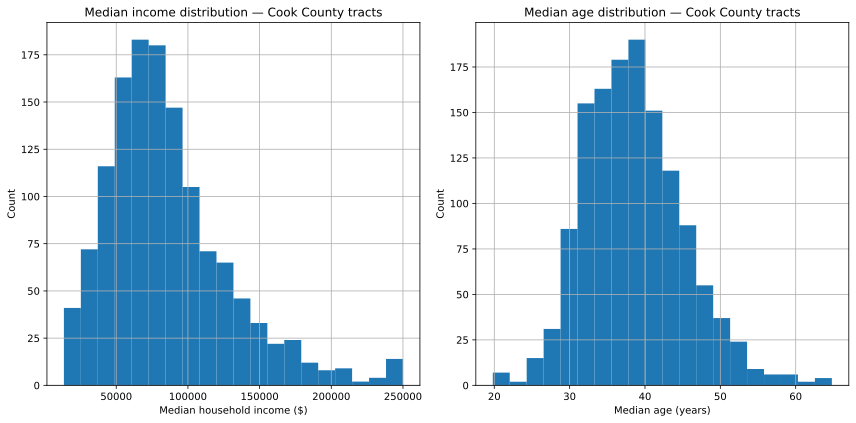

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

county_tract_acs_df["median_income"].dropna().hist(bins=20, ax=axes[0])
axes[0].set_xlabel("Median household income ($)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Median income distribution — {county_name} tracts")

county_tract_acs_df["median_age"].dropna().hist(bins=20, ax=axes[1])
axes[1].set_xlabel("Median age (years)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Median age distribution — {county_name} tracts")

plt.tight_layout()
plt.show()

We can also look at which tracts have the highest public transit commute share — a natural variable of interest in a city like Chicago.

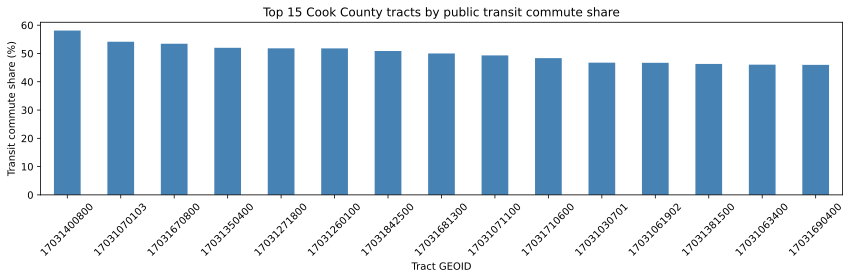

In [ ]:
top_transit = (
    county_tract_acs_df["transit_pct"]
    .dropna()
    .sort_values(ascending=False)
    .head(15)
)
ax = top_transit.plot.bar(figsize=(12, 4), color="steelblue")
ax.set_xlabel("Tract GEOID")
ax.set_ylabel("Transit commute share (%)")
ax.set_title(f"Top 15 {county_name} tracts by public transit commute share")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### DISCUSSION: Optimizing viz

While it does have interesting info, this not a very informative viz!  How could you improve it?

Next, let's peek at occupational variables!

In [ ]:
occupation_by_median_earnings_columns = {
    "B24011_002E": "Mgmt/Biz/Science/Arts",         # Management, business, science, and arts occupations
    "B24011_018E": "Service",                       # Service occupations
    "B24011_026E": "Sales/Office",                  # Sales and office occupations
    "B24011_029E": "NatRes/Construc/Maint",         # Natural resources, construction, and maintenance occupations
    "B24011_033E": "Produc/Transport/MatMoving",    # Production, transportation, and material moving occupations
}

In [ ]:
# @title This cell does the standard processing for our occupation columns and stores the data in `county_tract_acs_occupation_df`.

occupation_columns = list(occupation_by_median_earnings_columns.keys())

county_tract_acs_occupation_df = pd.DataFrame(
    census.acs5.get(
        occupation_columns,
        geo={
            "for": "tract:*",  # Note: we changed the "for" statement to include tracts instead of blocks
            "in": f"county:{county_fips} state:{state_fips}",
        },
        year=2023,
    )
)
county_tract_acs_occupation_df = county_tract_acs_occupation_df.rename(columns=occupation_by_median_earnings_columns)

county_tract_acs_occupation_df["GEOID"] = (
    county_tract_acs_occupation_df["state"]
    + county_tract_acs_occupation_df["county"]
    + county_tract_acs_occupation_df["tract"]
)
county_tract_acs_occupation_df = county_tract_acs_occupation_df.set_index("GEOID")
county_tract_acs_occupation_df = county_tract_acs_occupation_df.drop(columns=["state", "county", "tract"])

sentinal_value_mask = county_tract_acs_occupation_df < 0
county_tract_acs_occupation_df[sentinal_value_mask] = np.nan


county_tract_acs_occupation_df

,Mgmt/Biz/Science/Arts,Service,Sales/Office,NatRes/Construc/Maint,Produc/Transport/MatMoving
GEOID,,,,,
17031010100,57766.0,28239.0,38403.0,35208.0,34858.0
17031010201,59986.0,27368.0,38700.0,32000.0,41817.0
17031010202,53104.0,33594.0,45192.0,NaN,38188.0
17031010300,66028.0,36250.0,50750.0,78710.0,NaN
17031010400,49478.0,34497.0,24754.0,64148.0,48235.0
...,...,...,...,...,...
17031844600,56713.0,11406.0,67944.0,NaN,150417.0
17031844700,64959.0,33203.0,15000.0,27200.0,38224.0
17031980000,NaN,NaN,NaN,NaN,NaN


In [ ]:
# # This is a backup cell to load the tract-level ACS occupation data.

# url = "https://raw.githubusercontent.com/ds-20195/notebooks/refs/heads/main/backup_data/Notebook2_IL_acs_county_tract_occupation_data.json"
# county_tract_acs_occupation_df = pd.read_json(url, convert_axes=False)
# county_tract_acs_occupation_df.index.name = "GEOID"

Let's meet a new kind of plot called a [boxplot](https://en.wikipedia.org/wiki/Box_plot) or box-and-whiskers plot. (Is it a good choice for this data?)  

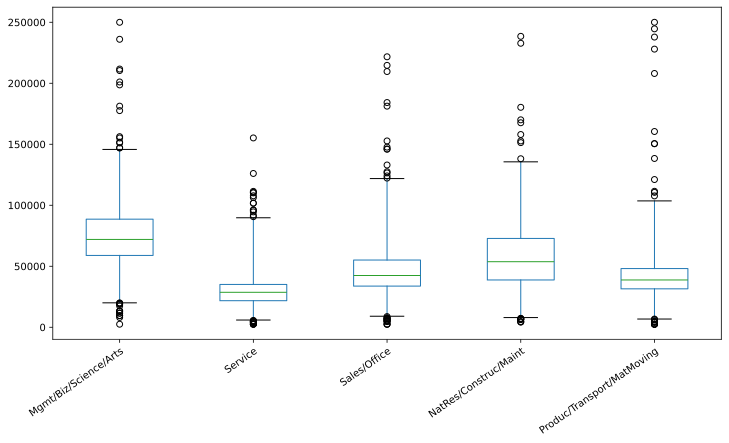

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
county_tract_acs_occupation_df.boxplot(
    ax=ax,
    rot=35, # rotate x-axis labels for readability
    whis=(1,99) # set whiskers to 1st and 99th percentiles
)

# turn off gridlines for better readability
ax.grid(False)

# adjust x-axis label alignment and rotation
for label in ax.get_xticklabels():
    label.set_ha("right")
    label.set_rotation_mode("anchor")

plt.show()

Now let's pull both income and education data, and then make a visualization that combines them.

In [ ]:
income_by_degree_columns = {
    "B20004_002E": "No degree",
    "B20004_003E": "High school diploma",
    "B20004_004E": "Associate's",
    "B20004_005E": "Bachelor's",
    "B20004_006E": "Master's",
    "B20004_007E": "Graduate / Professional",
}

In [ ]:
# @title This cell pulls education data for all counties in the state, and saves it to `county_acs_education_df`
education_columns = list(income_by_degree_columns.keys())

county_acs_education_df = pd.DataFrame(
    census.acs5.get(
        ["NAME"] + education_columns,
        geo={
            "for": "county:*",
            "in": f"state:{state_fips}",
        },
        year=2023,
    )
)
county_acs_education_df = county_acs_education_df.rename(
    columns=income_by_degree_columns
)

county_acs_education_df["GEOID"] = (
    county_acs_education_df["state"] + county_acs_education_df["county"]
)
county_acs_education_df = county_acs_education_df.set_index("GEOID")
county_acs_education_df = county_acs_education_df.drop(columns=["state", "county"])

sentinal_value_mask = (
    county_acs_education_df[list(income_by_degree_columns.values())] < 0
)
county_acs_education_df[sentinal_value_mask] = np.nan

county_acs_education_df

,NAME,No degree,High school diploma,Associate's,Bachelor's,Master's,Graduate / Professional
GEOID,,,,,,,
17001,"Adams County, Illinois",34492.0,40281.0,40960.0,57550.0,67372.0,52205.0
17003,"Alexander County, Illinois",18092.0,43900.0,33871.0,41042.0,55550.0,46588.0
17005,"Bond County, Illinois",29519.0,34897.0,32626.0,51325.0,61546.0,48684.0
17007,"Boone County, Illinois",33445.0,42898.0,50689.0,71192.0,95680.0,61185.0
17009,"Brown County, Illinois",23750.0,43523.0,46406.0,51250.0,59286.0,49071.0
...,...,...,...,...,...,...,...
17195,"Whiteside County, Illinois",37115.0,40409.0,43100.0,59491.0,68839.0,53645.0
17197,"Will County, Illinois",35580.0,44656.0,53481.0,76481.0,91536.0,72491.0
17199,"Williamson County, Illinois",21641.0,37349.0,42131.0,59761.0,77307.0,52655.0


In [ ]:
# # This is a backup cell to load the tract-level ACS education data.

# url = "https://raw.githubusercontent.com/ds-20195/notebooks/refs/heads/main/backup_data/Notebook2_IL_acs_county_education_data.json"
# county_acs_education_df = pd.read_json(url)

Matplotlib does not have an all-in-one function for making a heatmap, but we can work with the more general `imshow` function to create one. This is more commonly used for displaying photographs (the colors are for pixels), hence the name.

We will take a 2D array of values and create a grid of colored squares where the color of each square corresponds to the value in  the array.

*Note for advanced users: the `seaborn` library (an alternative to matplotlib) has a built-in function named `heatmap`, but we're sticking with matplotlib for simplicity.*

In [ ]:
fig, ax = plt.subplots(figsize=(9, 24))

# imshow
image_object = ax.imshow(
    pd.DataFrame(county_acs_education_df[list(income_by_degree_columns.values())]),
    aspect="auto",
    cmap="viridis",
    vmin=20000,
)


# Now we need to adjust the tick labels to show the degree categories and county names
# instead of numbers. Don't worry about this part: it's a bit of a pain to get right but
# it's just fiddly formatting code.
ax.set_xticks(range(len(income_by_degree_columns))) # make one tick for each degree category
ax.xaxis.tick_top() # move x-axis ticks to the top of the plot
ax.xaxis.set_label_position("top") # move x-axis label to the top as well

# Adjust x-axis tick labels to show degree categories
ax.set_xticklabels(
    list(income_by_degree_columns.values()),
    rotation=30,
    ha="left",  # adjust horizontal alignment of x-axis labels for better readability
)

ax.set_yticks(range(len(county_acs_education_df)))
ax.set_yticklabels(
    # We need to add the '.str' to tell pandas to apply the string replacement to each value in
    # the "NAME" column of the dataframe.
    county_acs_education_df["NAME"].str.replace("County, Illinois", "")
)

ax.set_title(
    f"Illinois Counties: Median Earnings by Educational Attainment\nACS 5-Year ({2023})",
    pad=5,
)

# Add in the color bar
fig.colorbar(image_object, ax=ax)

plt.show()

### TASK 3

Make a **scatterplot** with median household income on the x-axis and median age on the y-axis, one point per tract. Label the axes and give the plot a title. What pattern do you see?

In [ ]:
# YOUR CODE HERE

# raise your hand and ask for help if you get stuck!

## Section 4 — Joining Decennial and ACS data

Both datasets use GEOID codes as identifiers, but at different scales:
- **Block GEOID**: 15 digits — state(2) + county(3) + tract(6) + block(4)
- **Tract GEOID**: 11 digits — state(2) + county(3) + tract(6)

Since both block and tract are on the central spine of the Census geographic hierarchy, we can get the tract GEOID for any block by taking the first 11 characters of its block GEOID. Then we aggregate block counts up to the tract level and join with the ACS data.

To get started working with the GEOIDs, let's begin by inspecting them.  `df.index` creates a list (technically a Pandas series) of just the index column.

In [ ]:
# List the indices
block_race_df.index

Index(['170310101002000', '170310101002003', '170310101002007',
       '170310101002010', '170310101003001', '170310101003004',
       '170310101003007', '170310101003010', '170310101001000',
       '170310101001001',
       ...
       '170319801001002', '170319801001003', '170319801001005',
       '170319801001006', '170319900000002', '170319900000005',
       '170319900000001', '170319900000003', '170319900000004',
       '170319900000006'],
      dtype='object', name='GEOID20', length=83018)

The important thing to observe here is that the index column is of type "str" – a string. In Notebook0, we introduced string operations like *slicing*.

Recall that, for instance,
```python
my_string = "thing"
my_string[1:3]
```

will return 'hi' (we've sliced from index 1 to index 3, which is not inclusive of the endpoint, so we get the characters in positions 1 and 2)

It's important to use `.str` here.  Without it, something like `block_race_df.index[:2]` would just return the first two items.

In [ ]:
# To get the tract GEOID, we take the first 11 characters of the full 15-digit block identifier
block_race_df["tract_GEOID"] = block_race_df.index.str[:11]
block_race_df

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct,tract_GEOID
GEOID20,,,,,,,,,,,,,,,,
170310101002000,40,138,3,0,0,18,14,213,18.779343,64.788732,1.408451,0.000000,0.0,8.450704,6.572770,17031010100
170310101002003,99,86,0,6,0,6,12,209,47.368421,41.148325,0.000000,2.870813,0.0,2.870813,5.741627,17031010100
170310101002007,66,152,1,15,0,17,29,280,23.571429,54.285714,0.357143,5.357143,0.0,6.071429,10.357143,17031010100
170310101002010,10,108,1,0,0,8,9,136,7.352941,79.411765,0.735294,0.000000,0.0,5.882353,6.617647,17031010100
170310101003001,102,21,0,7,0,1,5,136,75.000000,15.441176,0.000000,5.147059,0.0,0.735294,3.676471,17031010100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170319900000005,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,17031990000
170319900000001,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,17031990000
170319900000003,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,17031990000


Now we need to aggregate the data in `block_race_df` up to the tract level. We do this using the `groupby` method for Pandas dataframes.

Warning!  Since we're just summing, the counts will be fine after applying `groupby`, but the percents will be screwed up.  We'll fix that before inspecting the dataframe.

In [ ]:
county_tract_race_df = block_race_df.groupby("tract_GEOID").aggregate("sum")

# Let's only keep the main pl_race_categories and then recompute percents, as mentioned above
county_tract_race_df = county_tract_race_df.loc[:, pl_race_categories + ["total"]]
for col in pl_race_categories:
    county_tract_race_df[f"{col}_pct"] = (
        100 * county_tract_race_df[col] / county_tract_race_df["total"]
    ).fillna(0)

# Let's sort by total population really quick to check for NaNs just in case
county_tract_race_df = county_tract_race_df.sort_values("total")
county_tract_race_df

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct
tract_GEOID,,,,,,,,,,,,,,,
17031990000,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
17031980000,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
17031980100,6,3,0,2,1,2,4,18,33.333333,16.666667,0.000000,11.111111,5.555556,11.111111,22.222222
17031381700,2,8,0,0,0,4,4,18,11.111111,44.444444,0.000000,0.000000,0.000000,22.222222,22.222222
17031381500,16,609,3,0,0,11,28,667,2.398801,91.304348,0.449775,0.000000,0.000000,1.649175,4.197901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17031320101,6124,482,23,1943,0,191,769,9532,64.246748,5.056651,0.241292,20.383970,0.000000,2.003777,8.067562
17031081403,6251,409,15,2182,5,191,790,9843,63.507061,4.155237,0.152393,22.168038,0.050798,1.940465,8.026008
17031839000,6173,1170,34,1924,7,330,797,10435,59.156684,11.212266,0.325827,18.437949,0.067082,3.162434,7.637758


We are now ready to join the dataframes. Since they both have the same index (tract GEOID), we can use the built-in Pandas `join` function.

In [ ]:
combined_df = county_tract_race_df.join(county_tract_acs_df)
combined_df

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct,median_age,median_income,commuters_total,transit_riders,transit_pct
tract_GEOID,,,,,,,,,,,,,,,,,,,,
17031990000,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.0,0.0,NaN
17031980000,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.0,0.0,NaN
17031980100,6,3,0,2,1,2,4,18,33.333333,16.666667,0.000000,11.111111,5.555556,11.111111,22.222222,NaN,NaN,0.0,0.0,NaN
17031381700,2,8,0,0,0,4,4,18,11.111111,44.444444,0.000000,0.000000,0.000000,22.222222,22.222222,NaN,NaN,0.0,0.0,NaN
17031381500,16,609,3,0,0,11,28,667,2.398801,91.304348,0.449775,0.000000,0.000000,1.649175,4.197901,59.4,25019.0,203.0,94.0,46.305419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17031320101,6124,482,23,1943,0,191,769,9532,64.246748,5.056651,0.241292,20.383970,0.000000,2.003777,8.067562,40.3,129221.0,6044.0,720.0,11.912641
17031081403,6251,409,15,2182,5,191,790,9843,63.507061,4.155237,0.152393,22.168038,0.050798,1.940465,8.026008,33.0,117550.0,6749.0,923.0,13.676100
17031839000,6173,1170,34,1924,7,330,797,10435,59.156684,11.212266,0.325827,18.437949,0.067082,3.162434,7.637758,30.5,95565.0,6367.0,1097.0,17.229464


Now that we've joined race and income in one dataframe, we can make a combined plot.

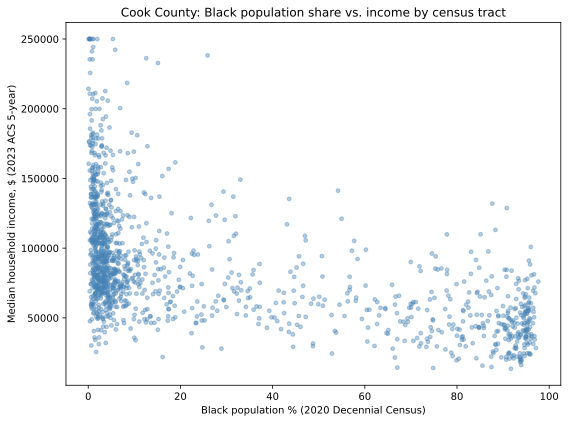

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    combined_df["Black_pct"],
    combined_df["median_income"],
    alpha=0.4, # the transparency of the markers
    s=15, # the size of the markers
    color="steelblue",
)
ax.set_xlabel("Black population % (2020 Decennial Census)")
ax.set_ylabel("Median household income, $ (2023 ACS 5-year)")
ax.set_title(f"{county_name}: Black population share vs. income by census tract")
plt.tight_layout()
plt.show()

## Homework 2

**Warmup question:** Among all Cook County census tracts with income data available, how many have a median household income above $100,000? What fraction of all tracts with data does that represent? Show your Pandas code.

**Data product:** This time we want you to figure out how to do something on your own. Go to the vast internet wilds and figure out how to fit a line to the last scatterplot above.  Explain what the line tells you, together with any extra information you want to provide about how best to interpret it. Now pick any other pair of variables in the Census and ACS data avaiable to you. Provide (a) a scatterplot with line fit, and (b) any other viz of your choice that helps tell a story about the relationship between your chosen variables.

_Tip: the [ACS table shells](https://www.census.gov/programs-surveys/acs/technical-documentation/table-shells.html) and the course [Google spreadsheet](https://docs.google.com/spreadsheets/d/1DtGNarbQLaJdtMiINQ7brQ-Y6zawBkkBkp0VGSENsZw/) are useful for finding variable codes._

**Reading response:** I hope you found the Hacking reading (*Making Up People*) to be delightful, but one sort of annoying thing is that he name-drops a lot of other people you may or may not have read. Let's unpack one reference. He reports that JS Mill thought of Horses as a "natural kind" but White Things as a "merely finite kind." Basically this means that horses have an inexhaustible number of things in common, while white objects quickly run out of commonalities -- it's basically just being white. He then considers race and religion, and concludes that they are more like merely finite kinds.  Is this persuasive?  Discuss briefly.